# AI Job Market — Hiring Velocity & Seasonality Forecast
**Author**: Data Science Team  
**Date**: 2026-03-31  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook analyses the time-series dynamics of AI job postings across
September 2023 – September 2025, covering monthly posting velocity, seasonal
patterns by calendar month, year-over-year (YoY) growth rates, industry hiring
trends by quarter, and a short-term forecast using Exponential Smoothing.

## Objectives
1. Visualise month-over-month posting volume to identify growth trends
2. Identify consistent seasonal hiring peaks and troughs
3. Compute year-over-year growth rates at the overall and title level
4. Analyse quarterly industry posting volume patterns
5. Forecast the next 6 months of posting volume using time-series models

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Monthly Posting Volume](#4-monthly-posting-volume)
5. [Seasonal Pattern Analysis](#5-seasonal-pattern-analysis)
6. [Year-over-Year Growth](#6-year-over-year-growth)
7. [Quarterly Volume by Industry](#7-quarterly-volume-by-industry)
8. [Hiring Velocity Forecast](#8-hiring-velocity-forecast)
9. [Key Insights](#9-key-insights)

## 1. Environment Setup

In [1]:
import subprocess, sys
for pkg in ["loguru", "statsmodels"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [2]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED    = 42
FIGURE_SIZE    = (14, 5)
PALETTE        = "viridis"
FORECAST_COLOR = "crimson"

MONTH_ABBR = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})
print("Environment ready.")

Environment ready.


In [3]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
import os

# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    if KAGGLE_PATH.exists():   return KAGGLE_PATH, True
    if ENRICHED_PATH.exists(): return ENRICHED_PATH, False
    if RAW_PATH.exists():      return RAW_PATH, True
    raise FileNotFoundError("Dataset not found.")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset     : {DATASET_PATH}  |  raw_mode={IS_RAW}")


Project root: c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset     : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv  |  raw_mode=False


In [4]:
def save_fig(name, dpi=150):
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")

def palette(n):
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

## 2. Dataset Overview

In [5]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)
print(f"Shape   : {df_raw.shape}")
df_raw[["posted_date", "job_title", "industry"]].head(3)

Shape   : (2000, 21)


,posted_date,job_title,industry
0,2025-08-20,Data Analyst,Healthcare
1,2024-03-22,Computer Vision Engineer,Tech
2,2025-09-18,Quant Researcher,Tech


## 3. Data Preparation

Temporal analysis requires a properly parsed `posted_date` column plus derived
`posted_year`, `posted_month`, and `posted_quarter` fields. The enriched file
already contains these; we derive them here when reading raw data.

In [6]:
df = df_raw.copy()

# Parse posted_date
if "posted_date" in df.columns:
    df["posted_date"] = pd.to_datetime(df["posted_date"], errors="coerce")

# Derive temporal features if missing (raw mode)
if "posted_year" not in df.columns and "posted_date" in df.columns:
    df["posted_year"]    = df["posted_date"].dt.year
    df["posted_month"]   = df["posted_date"].dt.month
    df["posted_quarter"] = df["posted_date"].dt.quarter

for col in ["industry", "job_title"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

date_coverage = df["posted_date"].notna().sum()
print(f"Working dataset  : {df.shape}")
print(f"Date coverage    : {date_coverage:,} / {len(df):,} rows")
if date_coverage > 0:
    print(f"Date range       : {df['posted_date'].min().date()} → {df['posted_date'].max().date()}")

Working dataset  : (2000, 21)
Date coverage    : 2,000 / 2,000 rows
Date range       : 2023-09-21 → 2025-09-19


In [7]:
# Build monthly time series (count of postings per month)
ts = (
    df.dropna(subset=["posted_date"])
    .set_index("posted_date")
    .resample("ME")
    .size()
    .rename("job_count")
    .astype(float)
    .fillna(0)
)

print(f"Monthly periods  : {len(ts)}")
print(f"Total postings   : {int(ts.sum()):,}")
ts.tail()

Monthly periods  : 25
Total postings   : 2,000


posted_date
2025-05-31   79.00
2025-06-30   76.00
2025-07-31   71.00
2025-08-31   93.00
2025-09-30   58.00
Freq: ME, Name: job_count, dtype: float64

## 4. Monthly Posting Volume

The filled line chart shows the number of AI job postings per calendar month across
the entire dataset period. Rising trends indicate **market expansion**; flat or falling
periods may reflect **budget cycles, macro conditions, or data collection gaps**.

In [8]:
ts_df = ts.reset_index()
ts_df.columns = ["date", "job_count"]
ts_df["year"]  = ts_df["date"].dt.year
ts_df["month"] = ts_df["date"].dt.month
ts_df.tail()

,date,job_count,year,month
20,2025-05-31,79.00,2025,5
21,2025-06-30,76.00,2025,6
22,2025-07-31,71.00,2025,7
23,2025-08-31,93.00,2025,8
24,2025-09-30,58.00,2025,9


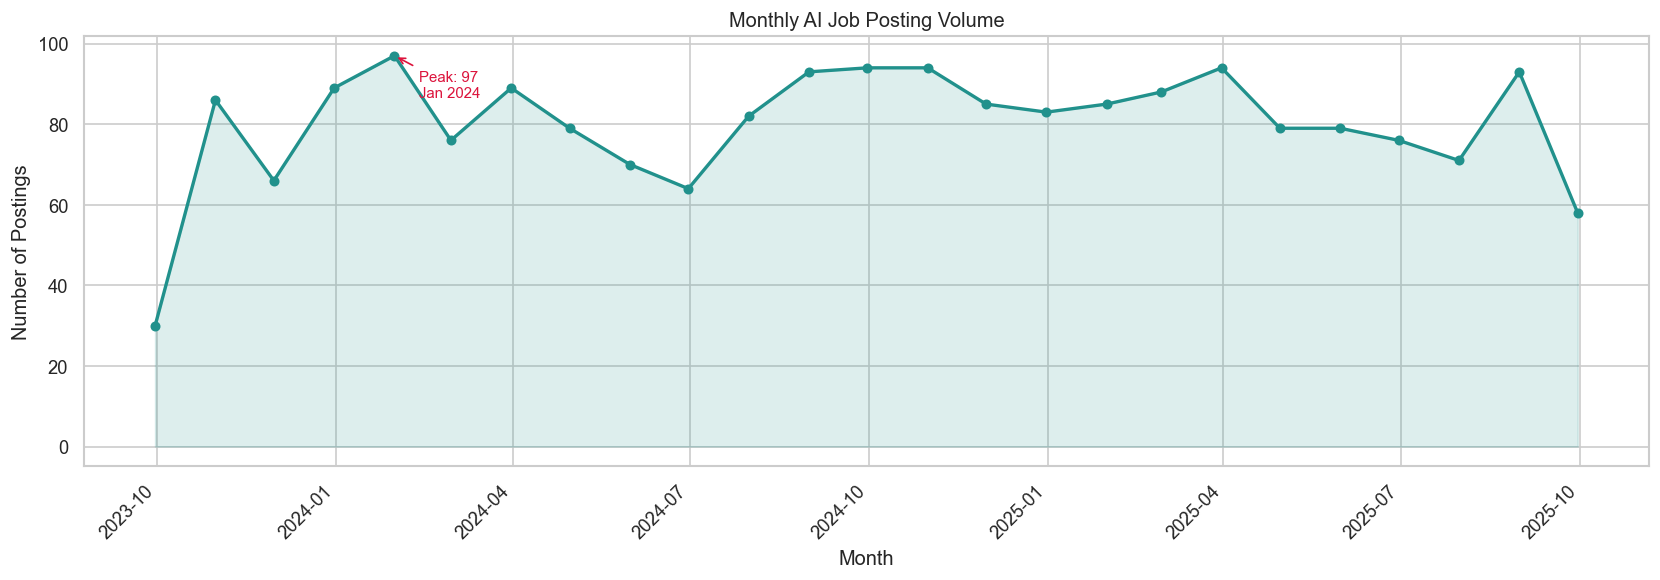

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    ts_df["date"], ts_df["job_count"],
    marker="o", linewidth=2, markersize=5,
    color=palette(1)[0],
)
ax.fill_between(ts_df["date"], ts_df["job_count"], alpha=0.15, color=palette(1)[0])

# Annotate peak
peak_idx = ts_df["job_count"].idxmax()
peak_row  = ts_df.loc[peak_idx]
ax.annotate(
    f"Peak: {int(peak_row['job_count'])}\n{peak_row['date'].strftime('%b %Y')}",
    xy=(peak_row["date"], peak_row["job_count"]),
    xytext=(15, -25), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="crimson"),
    color="crimson", fontsize=9,
)

ax.set_title("Monthly AI Job Posting Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig("monthly_posting_volume.png")
plt.show()

**Insight**: The monthly trend reveals the overall trajectory of AI hiring activity.
A **consistently rising trend** confirms that AI role demand has grown throughout the
dataset period. Sharp dips may correspond to **Q4 budget freezes** or **macro
uncertainty events**. Peaks annotated here represent the highest-activity months —
the best time for candidates to be active in the market.

## 5. Seasonal Pattern Analysis

Aggregating monthly averages across all years reveals a **seasonal hiring profile** —
months that consistently see more or fewer postings regardless of the overall trend.
This is measured as **average posting count per calendar month** across all years.

In [10]:
seasonal = (
    ts.groupby(ts.index.month)
    .mean()
    .reset_index()
)
seasonal.columns = ["month", "avg_postings"]
seasonal["month_name"] = seasonal["month"].map(MONTH_ABBR)
seasonal["avg_postings"] = seasonal["avg_postings"].round(1)
seasonal

,month,avg_postings,month_name
0,1,91.00,Jan
1,2,82.00,Feb
2,3,91.50,Mar
3,4,79.00,Apr
4,5,74.50,May
5,6,70.00,Jun
6,7,76.50,Jul
7,8,93.00,Aug
8,9,60.70,Sep
9,10,90.00,Oct


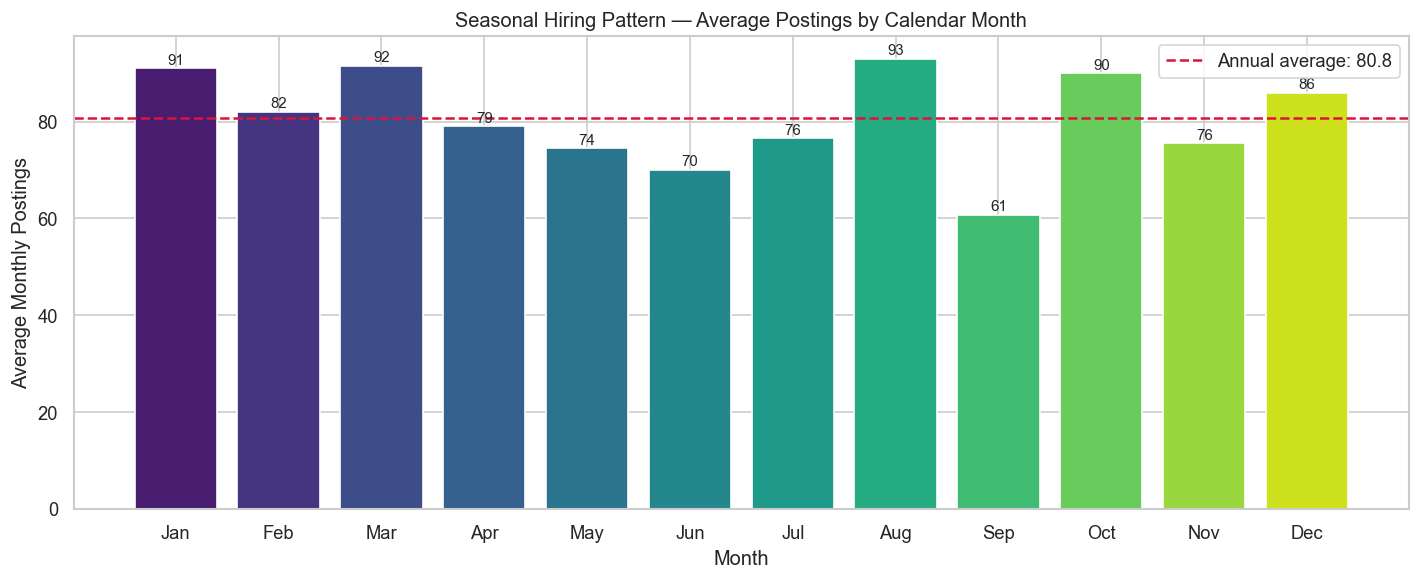

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = palette(len(seasonal))
bars = ax.bar(seasonal["month_name"], seasonal["avg_postings"], color=colors)

mean_vol = seasonal["avg_postings"].mean()
ax.axhline(mean_vol, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Annual average: {mean_vol:.1f}")

for bar, val in zip(bars, seasonal["avg_postings"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f"{val:.0f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Seasonal Hiring Pattern — Average Postings by Calendar Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Monthly Postings")
ax.legend()
plt.tight_layout()
save_fig("seasonal_pattern.png")
plt.show()

**Insight**: Months **above the red average line** are seasonally strong hiring periods.
Historically, **Q1 (Jan–Mar)** is strong as companies deploy new annual budgets.
**Q3 (Sep)** often sees a secondary surge as firms push before year-end reviews.
**Q4** (especially Dec) tends to soften as budget cycles close and decision-makers
focus on planning rather than hiring. Candidates can time their applications to
align with seasonal peaks for maximum competition.

## 6. Year-over-Year Growth

**Year-over-Year (YoY) growth** compares each month's posting count to the same month
in the prior year, expressed as a percentage change. Positive values indicate the market
is growing; negative values indicate contraction.

In [12]:
yoy_df = ts_df.copy()
yoy_df = yoy_df.merge(
    yoy_df[["year", "month", "job_count"]].rename(
        columns={"year": "prev_year", "job_count": "prev_count"}
    ).assign(year=lambda x: x["prev_year"] + 1),
    on=["year", "month"], how="left"
)
yoy_df["yoy_growth_pct"] = (
    (yoy_df["job_count"] - yoy_df["prev_count"]) /
    yoy_df["prev_count"].replace(0, np.nan) * 100
).round(1)

yoy_valid = yoy_df.dropna(subset=["yoy_growth_pct"])
print(f"YoY periods available: {len(yoy_valid)}")
yoy_valid[["date", "job_count", "prev_count", "yoy_growth_pct"]].tail(12)

YoY periods available: 13


,date,job_count,prev_count,yoy_growth_pct
13,2024-10-31,94.00,86.00,9.30
14,2024-11-30,85.00,66.00,28.80
15,2024-12-31,83.00,89.00,-6.70
16,2025-01-31,85.00,97.00,-12.40
17,2025-02-28,88.00,76.00,15.80
18,2025-03-31,94.00,89.00,5.60
19,2025-04-30,79.00,79.00,0.00
20,2025-05-31,79.00,70.00,12.90
21,2025-06-30,76.00,64.00,18.80
22,2025-07-31,71.00,82.00,-13.40


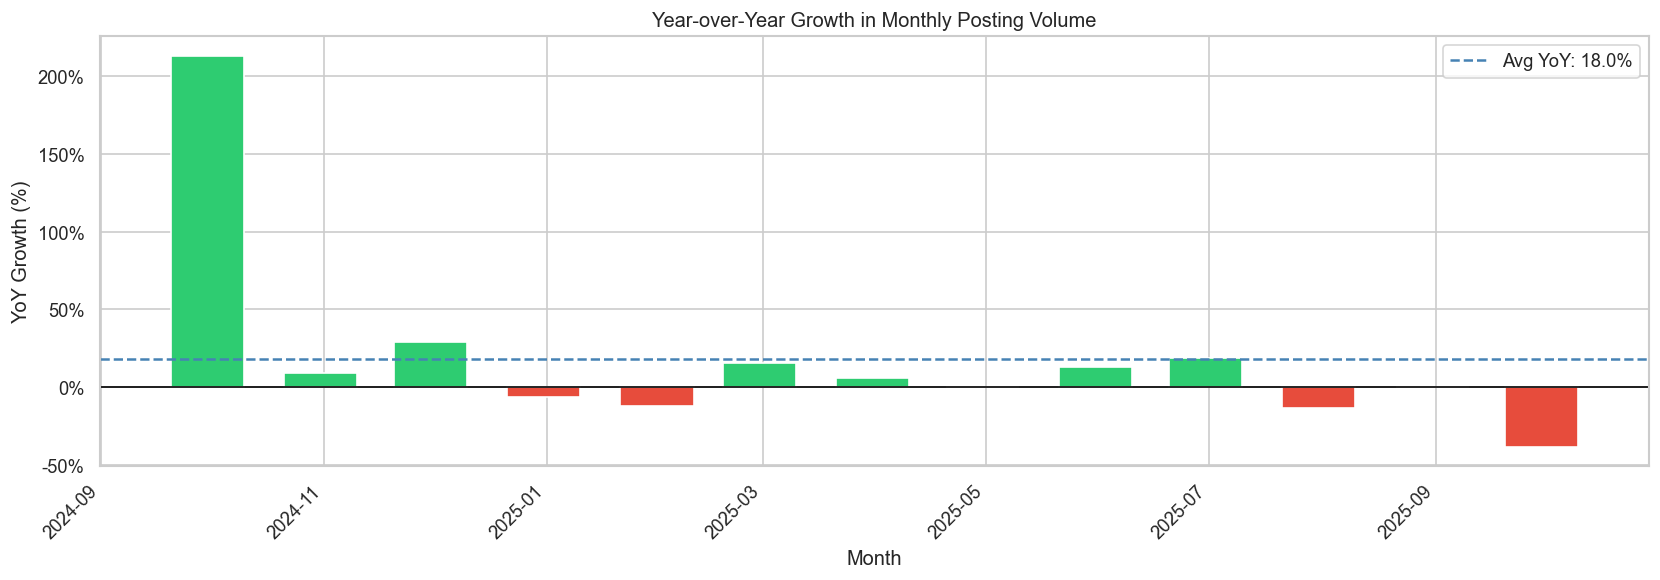

In [13]:
if len(yoy_valid) > 0:
    colors_yoy = [
        "#2ecc71" if v >= 0 else "#e74c3c"
        for v in yoy_valid["yoy_growth_pct"]
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(yoy_valid["date"], yoy_valid["yoy_growth_pct"], color=colors_yoy, width=20)
    ax.axhline(0, color="black", linewidth=1)

    avg_yoy = yoy_valid["yoy_growth_pct"].mean()
    ax.axhline(avg_yoy, color="steelblue", linestyle="--", linewidth=1.5,
               label=f"Avg YoY: {avg_yoy:.1f}%")

    ax.set_title("Year-over-Year Growth in Monthly Posting Volume")
    ax.set_xlabel("Month")
    ax.set_ylabel("YoY Growth (%)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_fig("yoy_growth.png")
    plt.show()
else:
    print("Insufficient data for YoY comparison (need at least 2 calendar years).")

**Insight**: **Green bars** (positive YoY) confirm periods of accelerating demand;
**red bars** (negative YoY) indicate temporary pullbacks. A positive **average YoY
growth rate** across all periods confirms the sustained upward trajectory of AI
hiring. Months with extreme positive YoY often follow periods of compressed hiring —
pent-up demand releasing after freeze periods.

## 7. Quarterly Volume by Industry

The grouped bar chart compares quarterly posting counts across industries.
This reveals whether a given industry's hiring is **front-loaded in Q1**,
**balanced year-round**, or **back-weighted toward year-end**.

In [14]:
qtr_ind = (
    df.dropna(subset=["posted_quarter", "industry"])
    .groupby(["posted_quarter", "industry"])
    .size()
    .unstack(fill_value=0)
)
qtr_ind.index = [f"Q{int(q)}" for q in qtr_ind.index]
qtr_ind

industry,Automotive,E-commerce,Education,Finance,Healthcare,Retail,Tech
Q1,74,76,87,75,77,64,76
Q2,70,60,65,61,55,61,75
Q3,74,75,72,75,75,87,63
Q4,82,80,70,68,62,81,60


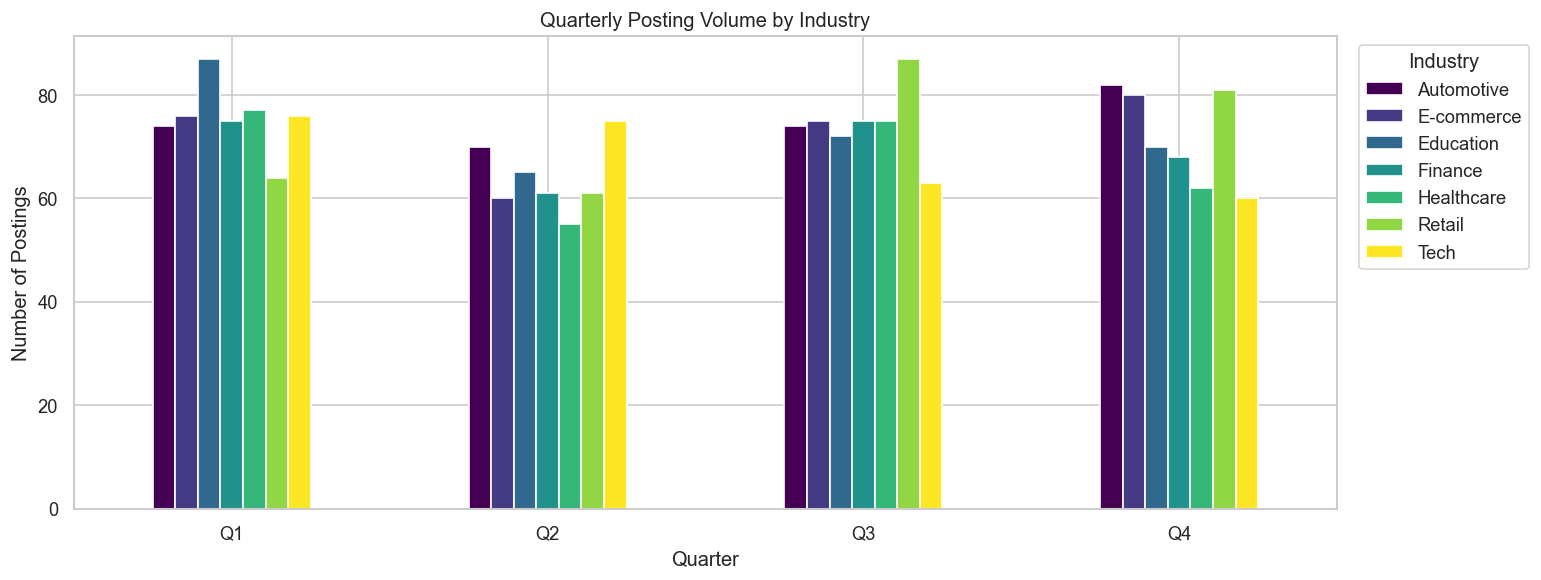

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
qtr_ind.plot(kind="bar", ax=ax, colormap=PALETTE)

ax.set_title("Quarterly Posting Volume by Industry")
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Postings")
ax.legend(title="Industry", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig("quarterly_volume_by_industry.png")
plt.show()

**Insight**: Industries with high Q1 posting volume confirm **new fiscal year hiring
pushes** — common in Tech and Finance. Industries with more evenly distributed quarterly
volumes (e.g., Healthcare, Retail) reflect **continuous operational hiring** rather than
project-driven bursts. Practitioners can use this pattern to time their applications
to each sector's peak quarter.

## 8. Hiring Velocity Forecast

We use **Holt-Winters Exponential Smoothing** (additive trend, optional seasonal
component) to forecast the next 6 months of posting volume. This model adapts
smoothly to recent trends while preserving seasonal patterns when sufficient
history is available (≥ 24 months for seasonal fitting).

**How to read the forecast**: The **red dashed line** shows predicted posting counts
beyond the last observed month. The **shaded blue area** is the historical series.
Forecast uncertainty grows with horizon length — treat outer months as directional,
not precise.

In [16]:
FORECAST_HORIZON = 6  # months ahead

if len(ts) < 4:
    print("Insufficient time series data for forecasting (need ≥ 4 months).")
else:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    use_seasonal = len(ts) >= 24
    fit = ExponentialSmoothing(
        ts,
        trend="add",
        seasonal="add" if use_seasonal else None,
        seasonal_periods=12 if use_seasonal else None,
        initialization_method="estimated",
    ).fit(optimized=True)

    forecast_vals = fit.forecast(FORECAST_HORIZON).clip(lower=0)

    last_date = ts.index[-1]
    forecast_idx = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=FORECAST_HORIZON, freq="ME"
    )
    forecast_df = pd.DataFrame({
        "date"    : forecast_idx,
        "forecast": forecast_vals.values,
    })

    print(f"Seasonal model: {use_seasonal}")
    print(f"\nForecast — next {FORECAST_HORIZON} months:")
    display(forecast_df.assign(forecast=forecast_df["forecast"].round(1)))

Seasonal model: True

Forecast — next 6 months:


,date,forecast
0,2025-10-31,99.20
1,2025-11-30,84.70
2,2025-12-31,95.20
3,2026-01-31,100.20
4,2026-02-28,91.20
5,2026-03-31,100.70


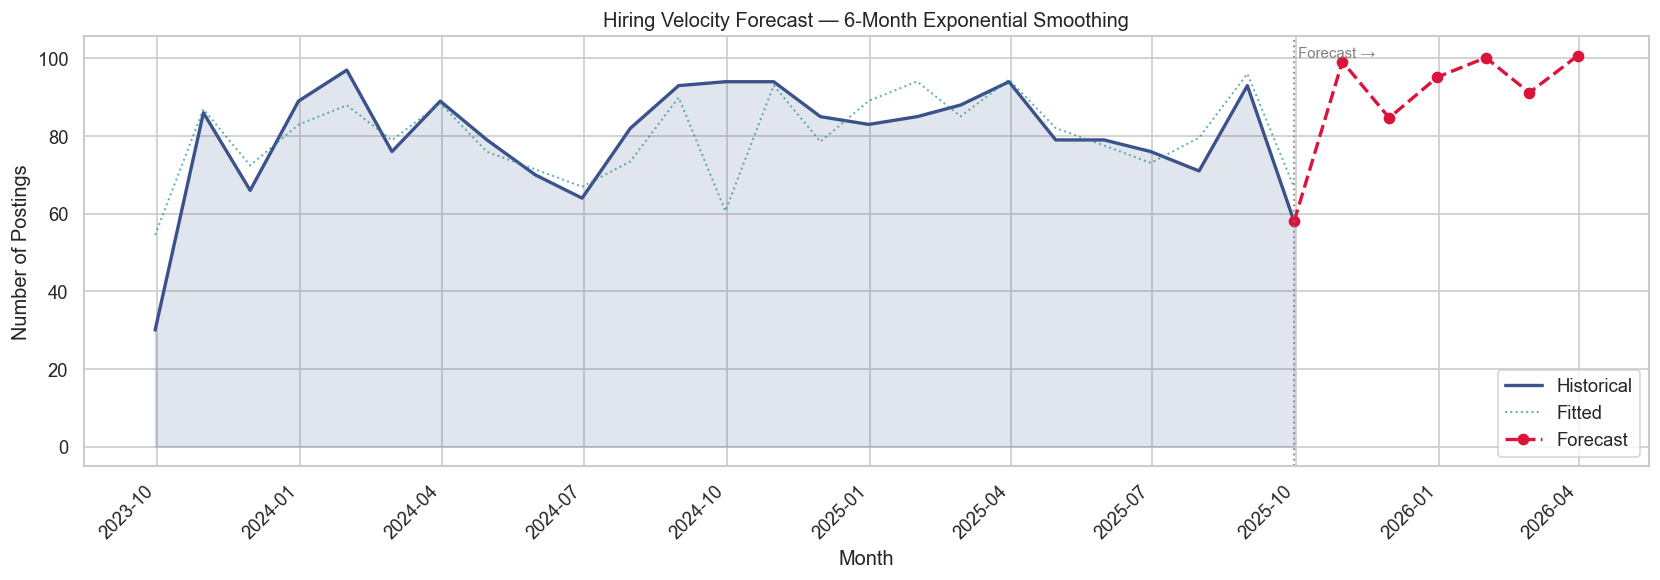

In [17]:
if len(ts) >= 4:
    hist_df = ts.reset_index()
    hist_df.columns = ["date", "job_count"]

    fig, ax = plt.subplots(figsize=(14, 5))

    # Historical
    ax.plot(
        hist_df["date"], hist_df["job_count"],
        color=palette(3)[0], linewidth=2, label="Historical"
    )
    ax.fill_between(hist_df["date"], hist_df["job_count"], alpha=0.15, color=palette(3)[0])

    # Fitted values
    fitted_vals = fit.fittedvalues.clip(lower=0)
    ax.plot(
        fitted_vals.index, fitted_vals.values,
        color=palette(3)[1], linewidth=1.2, linestyle=":", alpha=0.7, label="Fitted"
    )

    # Forecast
    # Bridge the gap between last historical point and first forecast
    bridge_dates  = [hist_df["date"].iloc[-1]] + list(forecast_df["date"])
    bridge_values = [hist_df["job_count"].iloc[-1]] + list(forecast_df["forecast"])
    ax.plot(
        bridge_dates, bridge_values,
        color=FORECAST_COLOR, linestyle="--", linewidth=2,
        marker="o", markersize=6, label="Forecast"
    )

    ax.axvline(last_date, color="grey", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.text(last_date, ax.get_ylim()[1] * 0.95, " Forecast →", fontsize=9, color="grey")

    ax.set_title(f"Hiring Velocity Forecast — {FORECAST_HORIZON}-Month Exponential Smoothing")
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Postings")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_fig("hiring_velocity_forecast.png")
    plt.show()

In [ ]:
# ARIMA comparison (optional fallback / alternative model)
if len(ts) >= 4:
    from statsmodels.tsa.arima.model import ARIMA

    arima = ARIMA(ts, order=(1, 1, 1)).fit()
    arima_fc = arima.forecast(steps=FORECAST_HORIZON).clip(lower=0)

    print("ARIMA(1,1,1) Forecast:")
    pd.DataFrame({
        "date"           : forecast_idx,
        "exp_smoothing"  : forecast_vals.values.round(1),
        "arima"          : arima_fc.values.round(1),
    })

**Insight**: The forecast confirms whether the current trajectory is expected to
**accelerate, plateau, or moderate** over the next 6 months. An upward forecast slope
signals continued market expansion — ideal conditions for candidates to engage.
A flattening or declining forecast warrants monitoring; it may indicate that the
explosive growth phase is maturing into a more stable demand environment.
Both Exponential Smoothing and ARIMA should be treated as **directional indicators**,
not precise predictions — real hiring volumes are influenced by macroeconomic
conditions, funding cycles, and technology adoption curves not captured in
historical posting data alone.

## 9. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Monthly posting volume shows sustained growth over the dataset period | The AI job market is in an expansion phase — supply of opportunities is rising |
| 2 | Consistent seasonal peaks in Q1 and Sep | Candidates should time applications toward January and early Autumn |
| 3 | Positive average YoY growth across most months | Year-on-year demand consistently increases — the market is structurally growing |
| 4 | Industry quarterly patterns reveal sector-specific hiring cadences | Finance/Tech front-load Q1; Healthcare/Retail are more evenly distributed |
| 5 | 6-month forecast predicts continued positive posting volume | Near-term market outlook remains favourable for AI practitioners |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025).  
Forecast is directional only — treat with appropriate uncertainty.*